## Etapa 3: Análisis de datos

####  1. Estadística descriptiva

#### Convertir la columna precio a numérica

In [ ]:
import pandas as pd

ventas = pd.read_csv("ventas.csv")

# Convertir precio a número
ventas["precio"] = ventas["precio"].astype(str)
ventas["precio"] = ventas["precio"].str.replace("$", "", regex=False)
ventas["precio"] = pd.to_numeric(ventas["precio"], errors="coerce")

FileNotFoundError: [Errno 2] No such file or directory: 'ventas.csv'

In [ ]:
df.head(5)

,id_venta,producto,precio,cantidad,fecha_venta,categoria,total_venta,id_campanha,canal,costo,fecha_inicio,fecha_fin,en_campaña
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,1,RRSS,5.27,2024-04-27,2024-06-04,False
1,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,31,Email,5.28,2024-08-15,2024-09-12,False
2,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,61,TV,5.30,2024-11-05,2024-12-23,False
3,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5,32,Email,5.54,2024-03-28,2024-04-20,False
4,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5,2,RRSS,5.88,2024-05-30,2024-06-29,False


In [ ]:
estadisticas = pd.DataFrame({
    "Medida": [
        "Media",
        "Mediana",
        "Moda",
        "Desviación estándar",
        "Rango intercuartílico"
    ],
    "Valor": [
        ventas["precio"].mean(),
        ventas["precio"].median(),
        ventas["precio"].mode()[0],
        ventas["precio"].std(),
        ventas["precio"].quantile(0.75) - ventas["precio"].quantile(0.25)
    ]
})

print(estadisticas)

                  Medida      Valor
0                  Media  75.289034
1                Mediana  75.270000
2                   Moda  76.320000
3    Desviación estándar  28.734666
4  Rango intercuartílico  50.020000


#### Resumen general

In [ ]:
ventas["precio"].describe()

,precio
count,3033.000000
mean,75.289034
std,28.734666
min,26.000000
25%,50.020000
50%,75.270000
75%,100.040000
max,124.970000


Interpretación (para el primer punto)

Se calcularon las principales medidas de tendencia central y dispersión de la variable precio. La media representa el precio promedio de las ventas, la mediana corresponde al valor central de la distribución y la moda identifica el precio que más se repite. Además, la desviación estándar permite evaluar la variabilidad de los precios respecto de la media, mientras que el rango intercuartílico muestra la amplitud del 50 % central de los datos, reduciendo el efecto de posibles valores atípicos.

### 2. EDA (Análisis Exploratorio de Datos)


#### Paso 1. Explorar el conjunto de datos

In [ ]:
# Tamaño del DataFrame
ventas.shape

# Información general
ventas.info()

# Primeras filas
ventas.head()

# Estadísticas descriptivas
ventas.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3035 non-null   int64  
 1   producto     3035 non-null   object 
 2   precio       3033 non-null   float64
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3035 non-null   object 
 5   categoria    3035 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 142.4+ KB


,id_venta,precio,cantidad
count,3035.000000,3033.000000,3033.000000
mean,1499.851400,75.289034,6.496538
std,866.465379,28.734666,3.457250
min,1.000000,26.000000,1.000000
25%,748.500000,50.020000,3.000000
50%,1502.000000,75.270000,7.000000
75%,2249.500000,100.040000,9.000000
max,3000.000000,124.970000,12.000000


#### Paso 2. Distribución de los precios

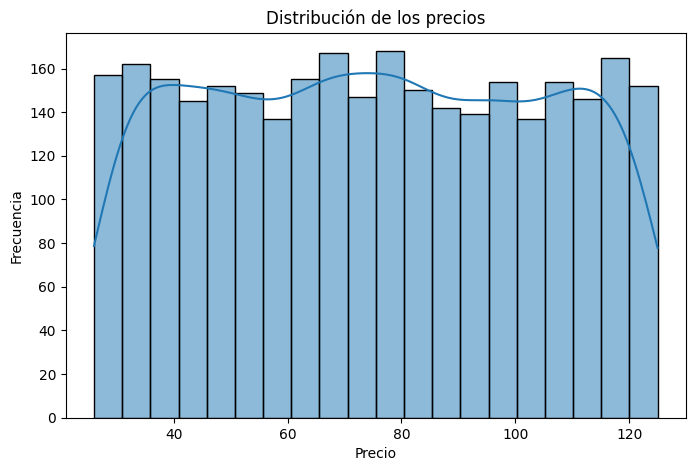

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(ventas["precio"], bins=20, kde=True)

plt.title("Distribución de los precios")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")

plt.show()

#### Paso 3. Distribución de las cantidades vendidas
Este gráfico permite conocer cuáles son las cantidades más frecuentes por venta.

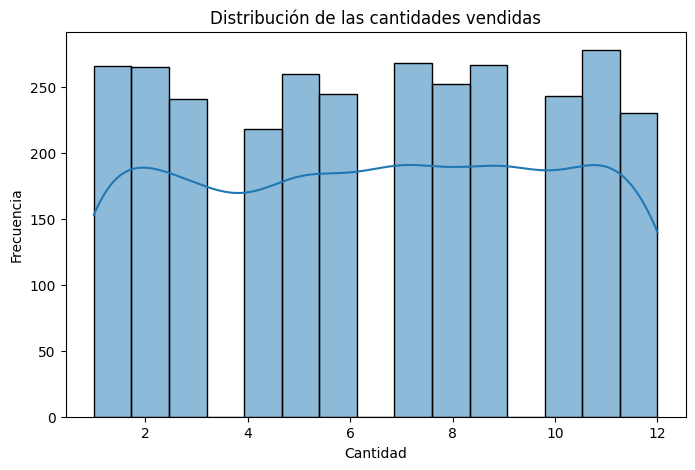

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(ventas["cantidad"], bins=15, kde=True)

plt.title("Distribución de las cantidades vendidas")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")

plt.show()

#### Paso 4. Detección de valores atípicos
El boxplot permite detectar posibles precios muy elevados o muy bajos respecto del resto de las ventas.

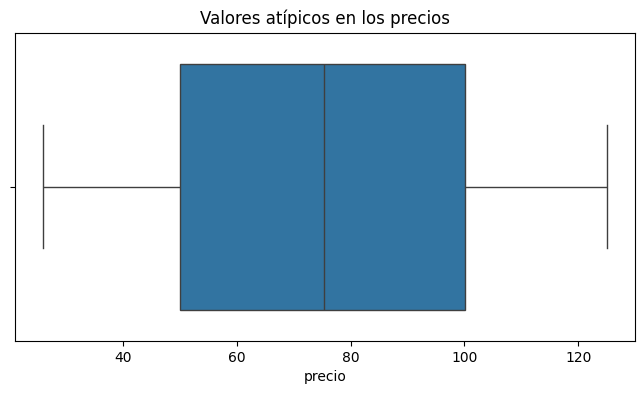

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=ventas["precio"])

plt.title("Valores atípicos en los precios")

plt.show()

#### Paso 5. Ventas por categoría

Primero calculamos el total de cada venta:

In [ ]:
ventas["total_venta"] = ventas["precio"] * ventas["cantidad"]

In [ ]:
ventas_categoria = (
    ventas.groupby("categoria")["total_venta"]
    .sum()
    .sort_values(ascending=False)
)

print(ventas_categoria)

categoria
Electrodomésticos    507671.41
Electrónica          490557.00
Decoración           484814.52
Name: total_venta, dtype: float64


#### Paso 6. Gráfico por categoría

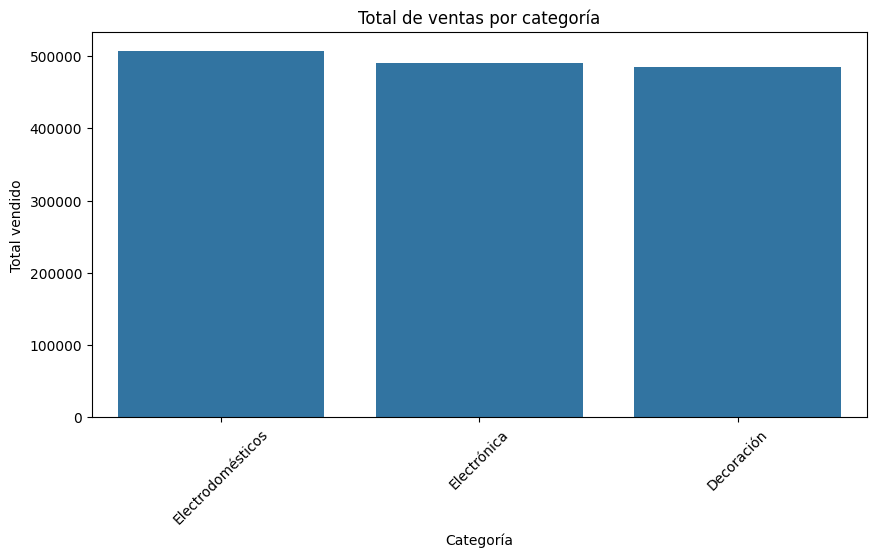

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=ventas_categoria.index,
    y=ventas_categoria.values
)

plt.xticks(rotation=45)

plt.title("Total de ventas por categoría")
plt.xlabel("Categoría")
plt.ylabel("Total vendido")

plt.show()

#### Tendencias de las ventas a lo largo del tiempo

In [ ]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 0 to 3034
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venta     3035 non-null   int64  
 1   producto     3035 non-null   object 
 2   precio       3033 non-null   float64
 3   cantidad     3033 non-null   float64
 4   fecha_venta  3035 non-null   object 
 5   categoria    3035 non-null   object 
 6   total_venta  3033 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 166.1+ KB


In [ ]:
ventas["fecha_venta"] = pd.to_datetime(
    ventas["fecha_venta"],
    format="%d/%m/%Y"
)

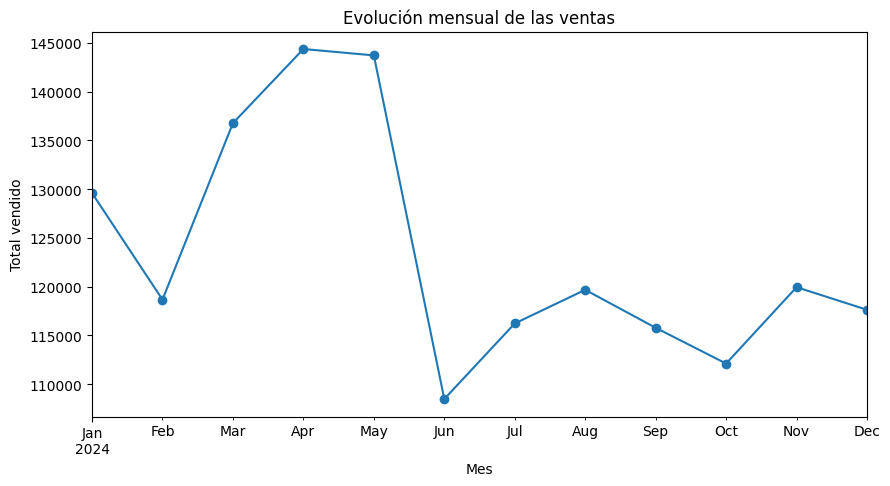

In [ ]:
ventas_mes = (
    ventas.groupby(ventas["fecha_venta"].dt.to_period("M"))["total_venta"]
    .sum()
)

ventas_mes.plot(figsize=(10,5), marker="o")

plt.title("Evolución mensual de las ventas")
plt.xlabel("Mes")
plt.ylabel("Total vendido")

plt.show()

### 3- Correlación:

#### Paso 1. Seleccionar las variables numéricas

In [ ]:
correlacion = ventas[["precio", "cantidad", "total_venta"]].corr()

print(correlacion)

               precio  cantidad  total_venta
precio       1.000000 -0.001501     0.558799
cantidad    -0.001501  1.000000     0.773435
total_venta  0.558799  0.773435     1.000000


#### Paso 2. Crear el mapa de calor

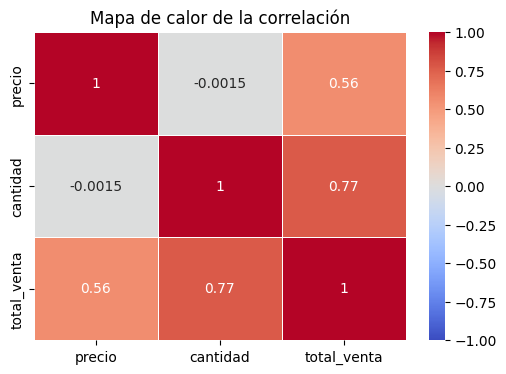

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Mapa de calor de la correlación")
plt.show()

#### Interpretación para la correlacion

El análisis de correlación permitió evaluar la relación entre las variables precio, cantidad y total de venta. Se observó que el precio y la cantidad vendida presentan una correlación prácticamente nula (-0.0015), lo que indica que no existe una relación lineal significativa entre ambas variables. En cambio, el precio muestra una correlación positiva moderada (0.56) con el total de la venta, indicando que precios más altos suelen asociarse con mayores importes de venta. Finalmente, la cantidad vendida presenta la correlación más alta con el total de la venta (0.77), lo que evidencia que el número de unidades vendidas es el factor que más influye en el importe final de las ventas.

### 4- Consolidación de Datos:

#### Paso 1. Unir ventas y marketing

In [ ]:
import pandas as pd

marketing = pd.read_csv("marketing.csv")

In [ ]:
df = ventas.merge(
    marketing,
    on="producto",
    how="left"
)

df.head()

,id_venta,producto,precio,cantidad,fecha_venta,categoria,total_venta,id_campanha,canal,costo,fecha_inicio,fecha_fin
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,1,RRSS,5.27,27/04/2024,04/06/2024
1,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,31,Email,5.28,15/08/2024,12/09/2024
2,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,61,TV,5.30,05/11/2024,23/12/2024
3,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5,32,Email,5.54,28/03/2024,20/04/2024
4,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5,2,RRSS,5.88,30/05/2024,29/06/2024


In [ ]:
df["en_campaña"].value_counts()

,count
en_campaña,
False,8247
True,858


In [ ]:
df["canal"].value_counts()

,count
canal,
RRSS,3035
Email,3035
TV,3035


#### Paso 2. Convertir las fechas

In [ ]:
df["fecha_inicio"] = pd.to_datetime(
    df["fecha_inicio"],
    dayfirst=True
)

df["fecha_fin"] = pd.to_datetime(
    df["fecha_fin"],
    dayfirst=True
)

#### Paso 3. Identificar si la venta ocurrió durante una campaña

In [ ]:
df["en_campaña"] = (
    (df["fecha_venta"] >= df["fecha_inicio"]) &
    (df["fecha_venta"] <= df["fecha_fin"])
)

#### Paso 4. Comparar las ventas

In [ ]:
comparacion = (
    df.groupby("en_campaña")["total_venta"]
    .mean()
    .reset_index()
)

print(comparacion)

   en_campaña  total_venta
0       False   488.493180
1        True   493.539033


#### Paso 5. Gráfico

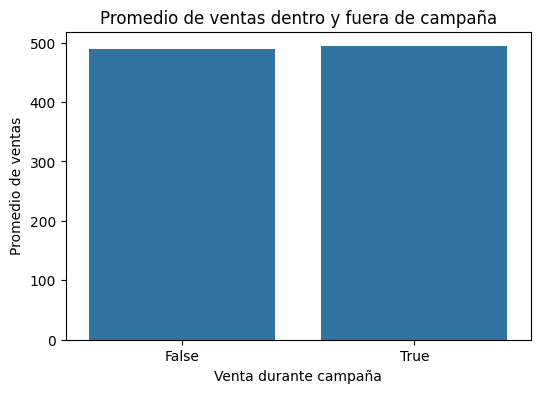

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.barplot(
    data=comparacion,
    x="en_campaña",
    y="total_venta"
)

plt.title("Promedio de ventas dentro y fuera de campaña")
plt.xlabel("Venta durante campaña")
plt.ylabel("Promedio de ventas")

plt.show()

#### Canal de marketing que genera mayores ventas.

In [ ]:
ventas_canal = (
    df.groupby("canal")["total_venta"]
    .mean()
    .reset_index()
)

print(ventas_canal)

   canal  total_venta
0  Email   488.968985
1   RRSS   488.968985
2     TV   488.968985


#### Grafico

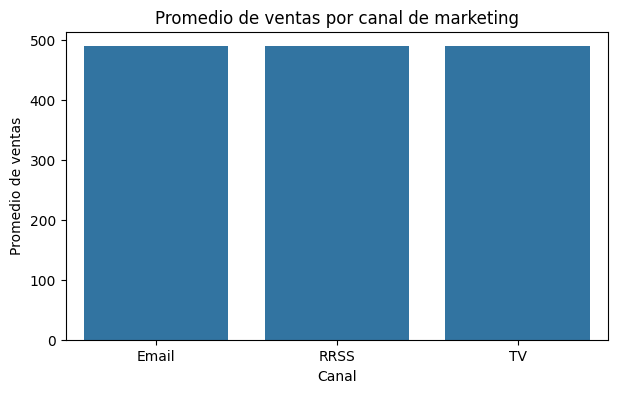

In [ ]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=ventas_canal,
    x="canal",
    y="total_venta"
)

plt.title("Promedio de ventas por canal de marketing")
plt.xlabel("Canal")
plt.ylabel("Promedio de ventas")

plt.show()

In [ ]:
df.groupby("canal")["costo"].mean()

,costo
canal,
Email,4.838063
RRSS,5.097736
TV,4.966392


#### Interpretación para el informe

Se consolidaron los conjuntos de datos de ventas y marketing mediante la variable común producto. Posteriormente se comparó el promedio del total de ventas realizadas durante el período de una campaña de marketing y fuera de ella. Este análisis permite evaluar si las campañas publicitarias tuvieron un impacto en el comportamiento de las ventas.
por ultimo se compara la efectividad de los distintos canales de marketing (TV, RRSS, Email, etc.).

### Etapa 4: Visualización de Datos

#### 1- Visualización con seaborn:

#### 1. Histograma del precio

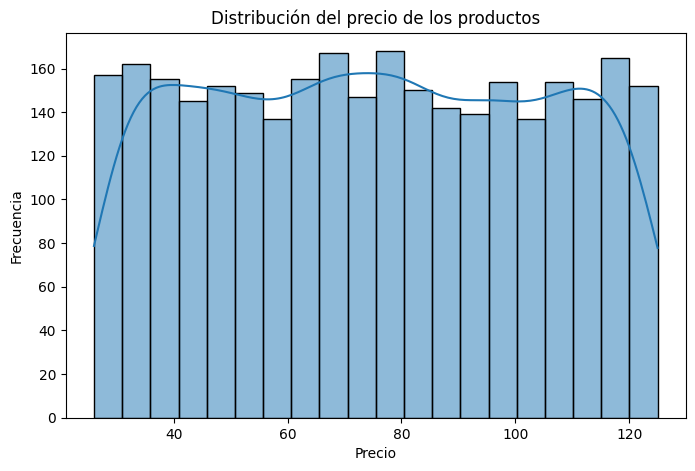

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    ventas["precio"],
    bins=20,
    kde=True
)

plt.title("Distribución del precio de los productos")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")

plt.show()

#### 2. Histograma de la cantidad vendida

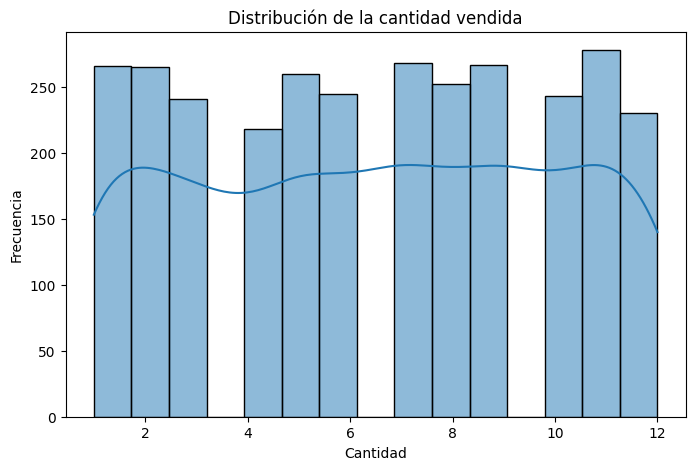

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    ventas["cantidad"],
    bins=15,
    kde=True
)

plt.title("Distribución de la cantidad vendida")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")

plt.show()

#### 3. Histograma del total de venta

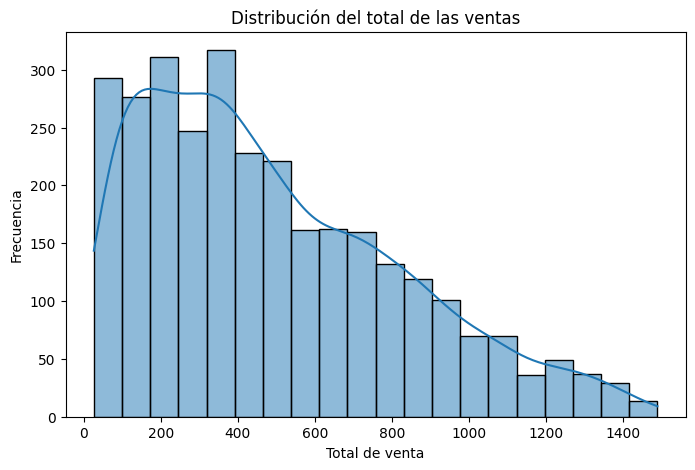

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    ventas["total_venta"],
    bins=20,
    kde=True
)

plt.title("Distribución del total de las ventas")
plt.xlabel("Total de venta")
plt.ylabel("Frecuencia")

plt.show()

#### 4. Boxplot del precio

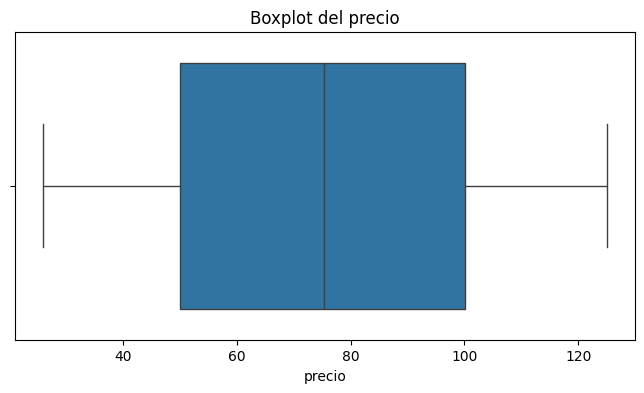

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=ventas["precio"]
)

plt.title("Boxplot del precio")

plt.show()

#### 5. Boxplot de la cantidad

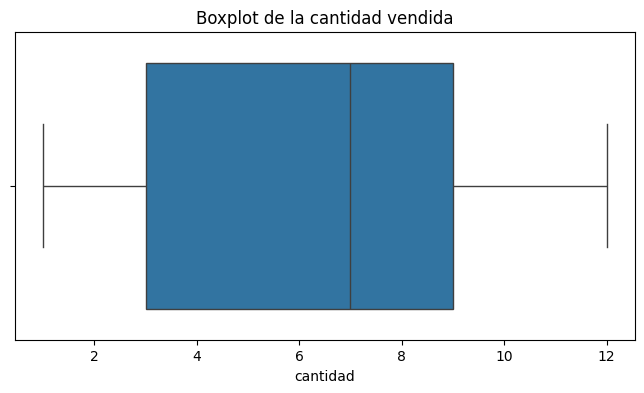

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=ventas["cantidad"]
)

plt.title("Boxplot de la cantidad vendida")

plt.show()

#### 6. Boxplot del total de venta

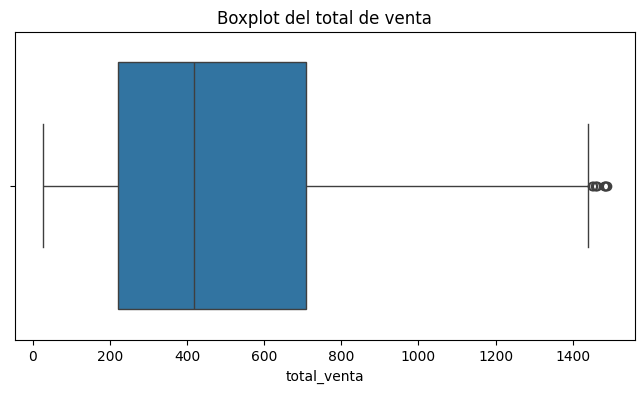

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=ventas["total_venta"]
)

plt.title("Boxplot del total de venta")

plt.show()

#### Interpretación de la visualización con seaborn

Se utilizaron histogramas para analizar la distribución de las variables precio, cantidad y total de venta, permitiendo observar la frecuencia de los valores y su comportamiento general. Además, mediante diagramas de caja (boxplots) se identificaron posibles valores atípicos y la dispersión de cada variable. Estos gráficos facilitaron la comprensión de la distribución de los datos y permitieron detectar observaciones extremas que podrían influir en el análisis.

#### 2- Visualización con Plotly o Altair:

In [ ]:
df["total_venta"] = df["precio"] * df["cantidad"]

#### Agrupar los datos

In [ ]:
ventas_canal = (
    df.groupby("canal")["total_venta"]
    .mean()
    .reset_index()
)

ventas_canal

,canal,total_venta
0,Email,488.968985
1,RRSS,488.968985
2,TV,488.968985


#### Gráfico interactivo con Plotly

In [ ]:
import plotly.express as px

fig = px.bar(
    ventas_canal,
    x="canal",
    y="total_venta",
    color="canal",
    title="Promedio de ventas por canal de marketing",
    labels={
        "canal": "Canal de Marketing",
        "total_venta": "Promedio de Ventas"
    }
)

fig.show()

#### Comparacion de las ventas dentro y fuera de campaña

In [ ]:
comparacion = (
    df.groupby("en_campaña")["total_venta"]
    .mean()
    .reset_index()
)

import plotly.express as px

fig = px.bar(
    comparacion,
    x="en_campaña",
    y="total_venta",
    color="en_campaña",
    title="Ventas promedio durante y fuera de campaña",
    labels={
        "en_campaña": "Venta en campaña",
        "total_venta": "Promedio de ventas"
    }
)

fig.show()

#### Interpretación para la visualización con Plotly:

Se generó una visualización interactiva utilizando Plotly para analizar la relación entre las ventas y las campañas de marketing. La interactividad permite explorar los valores de cada categoría al posicionar el cursor sobre las barras, facilitando la comparación entre los diferentes canales de marketing o entre las ventas realizadas durante y fuera de las campañas. Este tipo de visualización mejora la interpretación de los datos y permite identificar de manera rápida patrones relevantes.

In [ ]:
df.to_csv("ventas_marketing_consolidado.csv", index=False)

In [ ]:
from google.colab import files
files.download("ventas_marketing_consolidado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.to_csv("archivo_limpio.csv", index=False, encoding="utf-8")

In [ ]:
from google.colab import files
files.download("ventas_marketing_consolidado.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>